## 1. Load & Verify Clean Dataset

This section loads the cleaned HR employee attrition dataset and verifies
its structure, data types, missing values, and duplicate records before
conducting exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Load Clean Dataset

Load the cleaned dataset generated during the data cleaning phase.

In [2]:
file_path = "../data/processed/hr_employee_attrition_clean.csv"

df = pd.read_csv(file_path)

df.head()

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


## Column Names

In [3]:
df.columns.tolist()

['age',
 'attrition',
 'business_travel',
 'daily_rate',
 'department',
 'distance_from_home',
 'education',
 'education_field',
 'employee_number',
 'environment_satisfaction',
 'gender',
 'hourly_rate',
 'job_involvement',
 'job_level',
 'job_role',
 'job_satisfaction',
 'marital_status',
 'monthly_income',
 'monthly_rate',
 'num_companies_worked',
 'over_time',
 'percent_salary_hike',
 'performance_rating',
 'relationship_satisfaction',
 'stock_option_level',
 'total_working_years',
 'training_times_last_year',
 'work_life_balance',
 'years_at_company',
 'years_in_current_role',
 'years_since_last_promotion',
 'years_with_curr_manager']

## Data Types

In [4]:
df.dtypes

age                           int64
attrition                       str
business_travel                 str
daily_rate                    int64
department                      str
distance_from_home            int64
education                     int64
education_field                 str
employee_number               int64
environment_satisfaction      int64
gender                          str
hourly_rate                   int64
job_involvement               int64
job_level                     int64
job_role                        str
job_satisfaction              int64
marital_status                  str
monthly_income                int64
monthly_rate                  int64
num_companies_worked          int64
over_time                       str
percent_salary_hike           int64
performance_rating            int64
relationship_satisfaction     int64
stock_option_level            int64
total_working_years           int64
training_times_last_year      int64
work_life_balance           

In [5]:
df.dtypes.value_counts()

int64    24
str       8
Name: count, dtype: int64

## Data Quality Check

In [6]:
quality_check = pd.DataFrame({
    "metric": [
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Rows",
        "Unique Employee Numbers"
    ],
    "values": [
        len(df),
        df.shape[1],
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df["employee_number"].nunique()
    ]
})

quality_check

,metric,values
0,Total Rows,1470
1,Total Columns,32
2,Missing Values,0
3,Duplicate Rows,0
4,Unique Employee Numbers,1470


## 2. EDA Readiness

The cleaned HR employee attrition dataset contains 1,470 employee records
and 32 analytical variables. No missing values or duplicate rows are present,
and EmployeeNumber remains unique across all records.

The dataset is therefore ready for exploratory data analysis.

## 3. Descriptive Statistics & Target Distribution

This section examines the statistical characteristics of numerical variables
and the distribution of categorical variables, with particular attention to
the employee attrition target.

In [7]:
numeric_summary = (
    df.select_dtypes(include="number")
      .describe()
      .T
      .round(2)
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0
daily_rate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
distance_from_home,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0
education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0
employee_number,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0
environment_satisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0
hourly_rate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0
job_involvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0
job_level,1470.0,2.06,1.11,1.0,1.00,2.0,3.00,5.0
job_satisfaction,1470.0,2.73,1.10,1.0,2.00,3.0,4.00,4.0


In [8]:
categorical_columns = df.select_dtypes(include="str").columns

categorical_summary = pd.DataFrame({
    "column": categorical_columns,
    "unique_count": [
        df[col].nunique()
        for col in categorical_columns
    ]
})

categorical_summary

,column,unique_count
0,attrition,2
1,business_travel,3
2,department,3
3,education_field,6
4,gender,2
5,job_role,9
6,marital_status,3
7,over_time,2


In [9]:
attrition_counts = df["attrition"].value_counts()

attrition_counts

attrition
No     1233
Yes     237
Name: count, dtype: int64

In [10]:
attrition_percentage = (
    df["attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

attrition_percentage

attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

In [11]:
attrition_summary = pd.DataFrame({
    "employee_count": attrition_counts,
    "percentage": attrition_percentage
})

attrition_summary

,employee_count,percentage
attrition,,
No,1233,83.88
Yes,237,16.12


In [12]:
attrition_ratio = (
    attrition_counts["No"] / attrition_counts["Yes"]
)

print(f"Attrition No : Yes ratio = {attrition_ratio:.2f} : 1")

Attrition No : Yes ratio = 5.20 : 1


### Business Interpretation

The dataset contains 1,470 employees, of which 237 employees experienced
attrition and 1,233 employees remained with the company.

The overall attrition rate is 16.12%, indicating that the attrition target
is imbalanced, with approximately 5.2 employees who stayed for every
employee who left.

This imbalance should be considered when interpreting attrition patterns,
particularly when comparing employee segments with different workforce sizes.

## 4. Attrition Comparison

In [13]:
comparison_columns = [
    "age",
    "monthly_income",
    "years_at_company",
    "total_working_years",
    "job_satisfaction",
    "job_level",
    "distance_from_home",
    "num_companies_worked",
    "years_in_current_role",
    "years_with_curr_manager"
]

attrition_comparison = (
    df.groupby("attrition")[comparison_columns]
      .mean()
      .round(2)
)

attrition_comparison

,age,monthly_income,years_at_company,total_working_years,job_satisfaction,job_level,distance_from_home,num_companies_worked,years_in_current_role,years_with_curr_manager
attrition,,,,,,,,,,
No,37.56,6832.74,7.37,11.86,2.78,2.15,8.92,2.65,4.48,4.37
Yes,33.61,4787.09,5.13,8.24,2.47,1.64,10.63,2.94,2.90,2.85


In [14]:
attrition_median_comparison = (
    df.groupby('attrition')[comparison_columns]
      .median()
      .round(2)
)

attrition_median_comparison

,age,monthly_income,years_at_company,total_working_years,job_satisfaction,job_level,distance_from_home,num_companies_worked,years_in_current_role,years_with_curr_manager
attrition,,,,,,,,,,
No,36.0,5204.0,6.0,10.0,3.0,2.0,7.0,2.0,3.0,3.0
Yes,32.0,3202.0,3.0,7.0,3.0,1.0,9.0,1.0,2.0,2.0


In [15]:
mean_comparison = (
    df.groupby("attrition")[comparison_columns]
      .mean()
      .T
)

mean_comparison["difference"] = (
    mean_comparison["Yes"] - mean_comparison["No"]
)

mean_comparison = mean_comparison.round(2)

mean_comparison

attrition,No,Yes,difference
age,37.56,33.61,-3.95
monthly_income,6832.74,4787.09,-2045.65
years_at_company,7.37,5.13,-2.24
total_working_years,11.86,8.24,-3.62
job_satisfaction,2.78,2.47,-0.31
job_level,2.15,1.64,-0.51
distance_from_home,8.92,10.63,1.72
num_companies_worked,2.65,2.94,0.30
years_in_current_role,4.48,2.90,-1.58
years_with_curr_manager,4.37,2.85,-1.52


## 5. Categorical Analysis

In [16]:
categorical_analysis = [
    "business_travel",
    "department",
    "education_field",
    "gender",
    "job_role",
    "marital_status",
    "over_time"
]

for column in categorical_analysis:
    result = (
        df.groupby(column)["attrition"]
          .value_counts(normalize=True)
          .unstack(fill_value=0)
          .mul(100)
          .round(2)
    )

    print(f"\n--- {column} ---")
    display(result)


--- business_travel ---


attrition,No,Yes
business_travel,,
Non-Travel,92.00,8.00
Travel_Frequently,75.09,24.91
Travel_Rarely,85.04,14.96



--- department ---


attrition,No,Yes
department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63



--- education_field ---


...

attrition,No,Yes
job_role,,
Healthcare Representative,93.13,6.87
Human Resources,76.92,23.08
Laboratory Technician,76.06,23.94
Manager,95.10,4.90
Manufacturing Director,93.10,6.90
Research Director,97.50,2.50
Research Scientist,83.90,16.10
Sales Executive,82.52,17.48
Sales Representative,60.24,39.76



--- marital_status ---


attrition,No,Yes
marital_status,,
Divorced,89.91,10.09
Married,87.52,12.48
Single,74.47,25.53



--- over_time ---


attrition,No,Yes
over_time,,
No,89.56,10.44
Yes,69.47,30.53


## 6. Attrition Visualization

In [17]:
attrition_distribution = (
    df["attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

attrition_distribution

attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

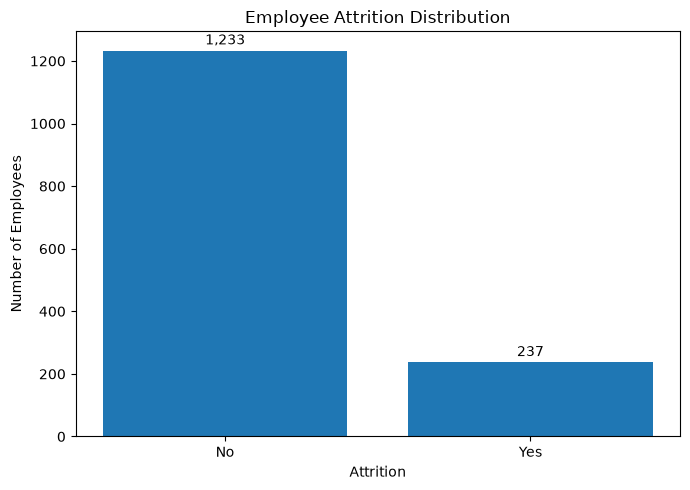

In [18]:
attrition_counts = df["attrition"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    attrition_counts.index,
    attrition_counts.values
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

for i, value in enumerate(attrition_counts.values):
    plt.text(
        i,
        value + 20,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

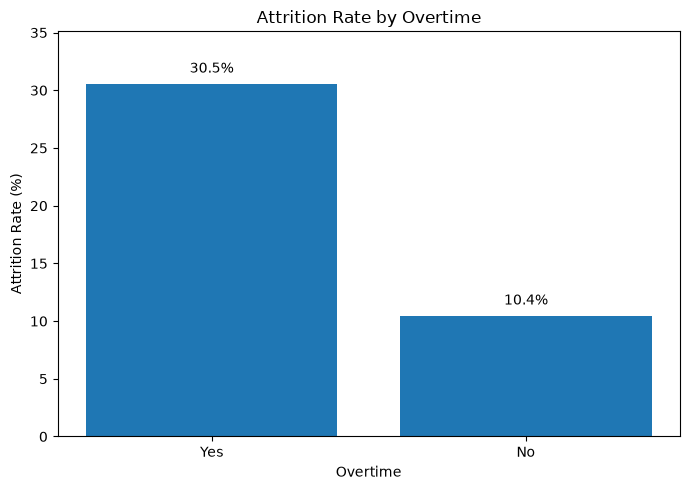

In [19]:
overtime_attrition = (
    df.groupby("over_time")["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

plt.bar(
    overtime_attrition.index,
    overtime_attrition.values
)

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

for i, value in enumerate(overtime_attrition.values):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, max(overtime_attrition.values) * 1.15)

plt.tight_layout()
plt.show()

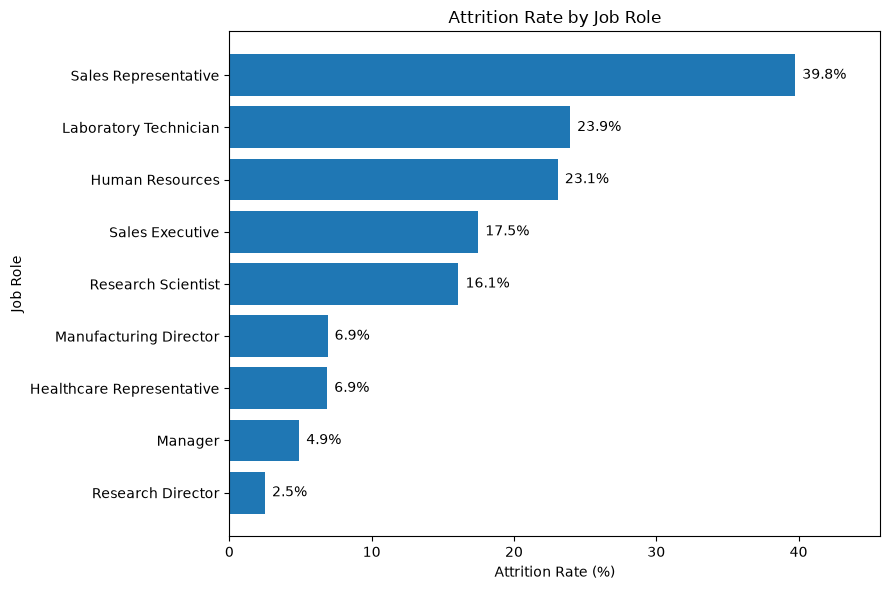

In [20]:
role_attrition = (
    df.groupby("job_role")["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values()
)

plt.figure(figsize=(9, 6))

plt.barh(
    role_attrition.index,
    role_attrition.values
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

for i, value in enumerate(role_attrition.values):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(0, max(role_attrition.values) * 1.15)

plt.tight_layout()
plt.show()

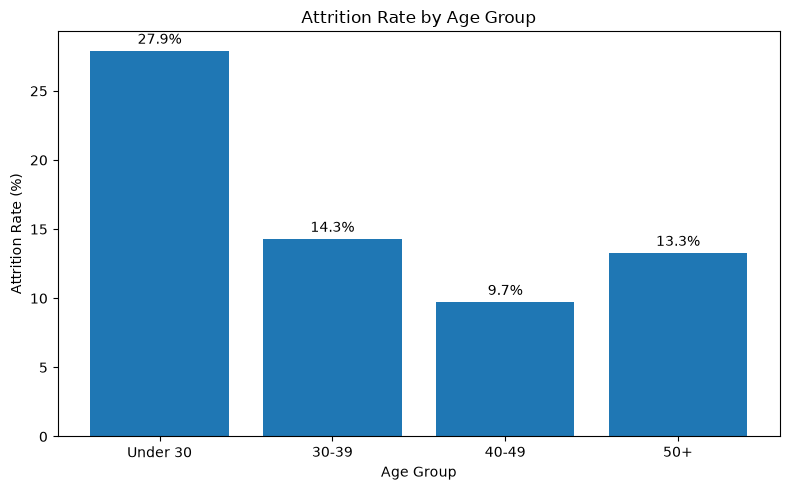

In [21]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 29, 39, 49, float("inf")],
    labels=["Under 30", "30-39", "40-49", "50+"]
)

age_attrition = (
    df.groupby("age_group", observed=True)["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

age_order = [
    "Under 30",
    "30-39",
    "40-49",
    "50+"
]

age_attrition = age_attrition.reindex(age_order)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    age_attrition.index,
    age_attrition.values
)

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")

for bar, value in zip(bars, age_attrition.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

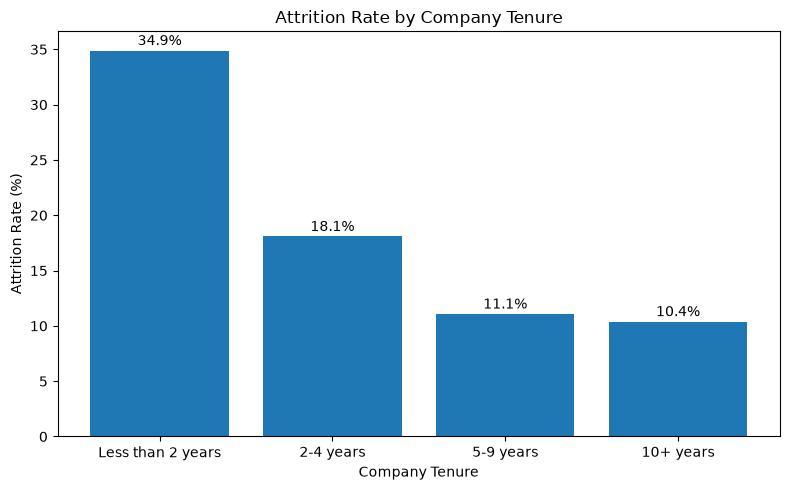

In [22]:
df["tenure_group"] = pd.cut(
    df["years_at_company"],
    bins=[-1, 1, 4, 9, float("inf")],
    labels=[
        "Less than 2 years",
        "2-4 years",
        "5-9 years",
        "10+ years"
    ]
)

tenure_attrition = (
    df.groupby("tenure_group", observed=True)["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    tenure_attrition.index,
    tenure_attrition.values
)

plt.title("Attrition Rate by Company Tenure")
plt.xlabel("Company Tenure")
plt.ylabel("Attrition Rate (%)")

for bar, value in zip(bars, tenure_attrition.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

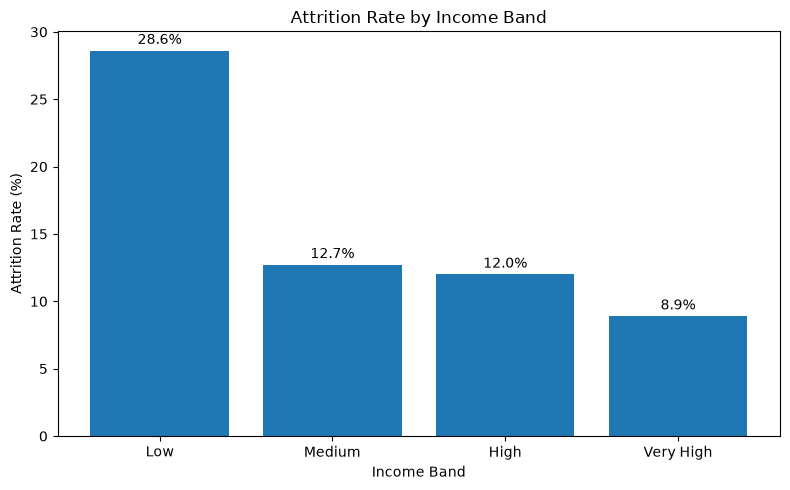

In [23]:
df["income_band"] = pd.cut(
    df["monthly_income"],
    bins=[0, 2999, 5999, 9999, float("inf")],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

income_attrition = (
    df.groupby("income_band", observed=True)["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    income_attrition.index,
    income_attrition.values
)

plt.title("Attrition Rate by Income Band")
plt.xlabel("Income Band")
plt.ylabel("Attrition Rate (%)")

for bar, value in zip(bars, income_attrition.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

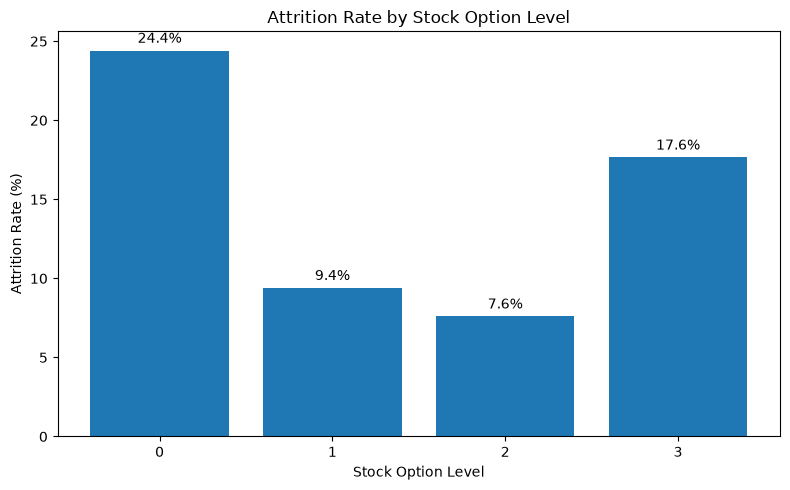

In [24]:
stock_option_attrition = (
    df.groupby("stock_option_level")["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    stock_option_attrition.index.astype(str),
    stock_option_attrition.values
)

plt.title("Attrition Rate by Stock Option Level")
plt.xlabel("Stock Option Level")
plt.ylabel("Attrition Rate (%)")

for bar, value in zip(bars, stock_option_attrition.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

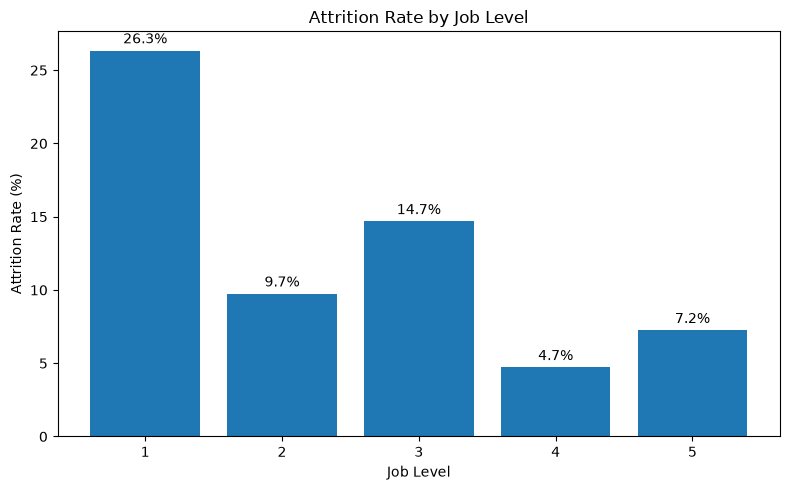

In [25]:
job_level_attrition = (
    df.groupby("job_level")["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    job_level_attrition.index.astype(str),
    job_level_attrition.values
)

plt.title("Attrition Rate by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")

for bar, value in zip(bars, job_level_attrition.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

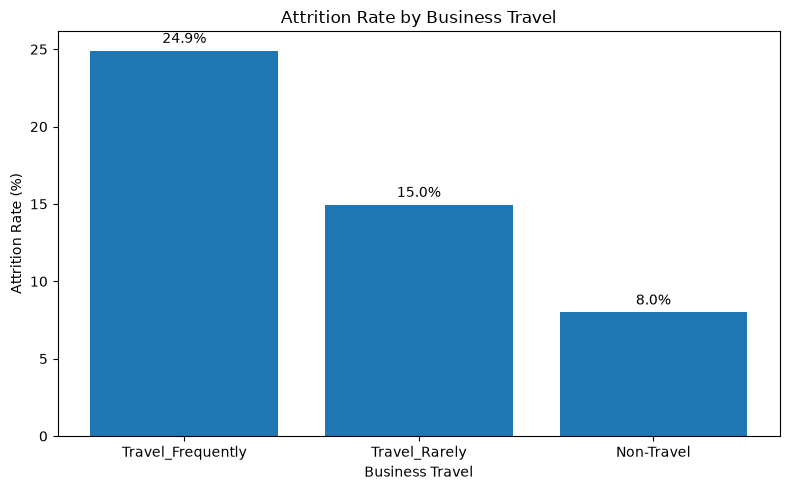

In [26]:
travel_attrition = (
    df.groupby("business_travel")["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    travel_attrition.index,
    travel_attrition.values
)

plt.title("Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")

for bar, value in zip(bars, travel_attrition.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

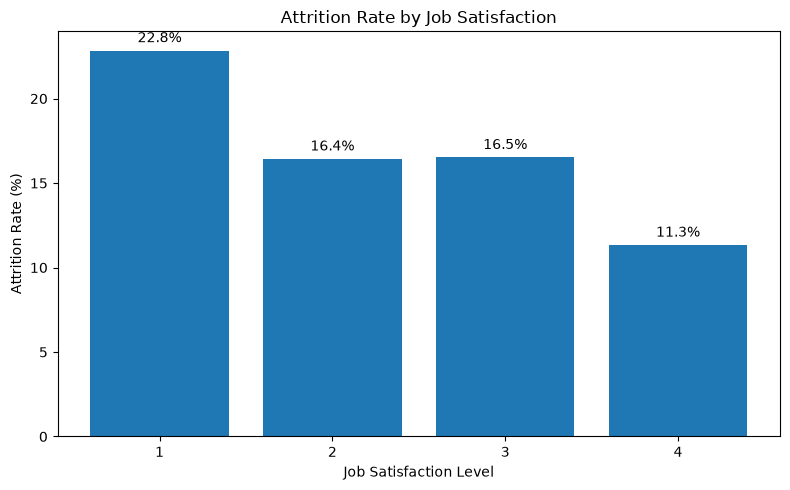

In [27]:
job_satisfaction_attrition = (
    df.groupby("job_satisfaction")["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    job_satisfaction_attrition.index.astype(str),
    job_satisfaction_attrition.values
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

for bar, value in zip(bars, job_satisfaction_attrition.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

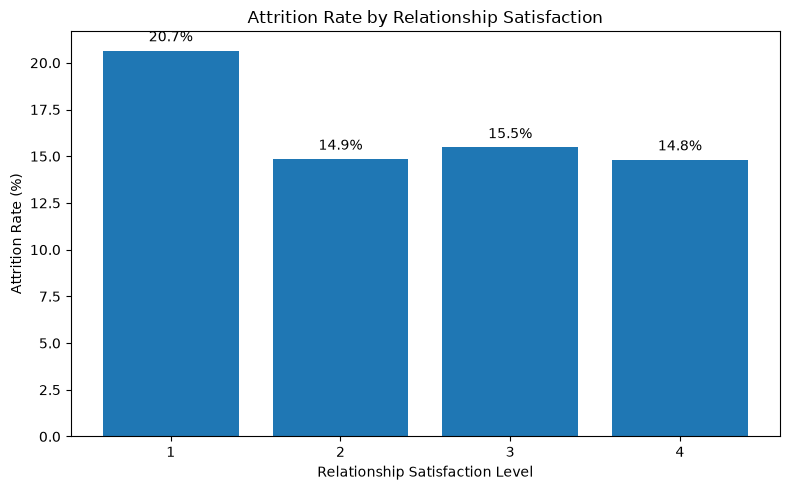

In [28]:
relationship_attrition = (
    df.groupby("relationship_satisfaction")["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

relationship_attrition = relationship_attrition.sort_index()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    relationship_attrition.index.astype(str),
    relationship_attrition.values
)

plt.title("Attrition Rate by Relationship Satisfaction")
plt.xlabel("Relationship Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

for bar, value in zip(bars, relationship_attrition.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

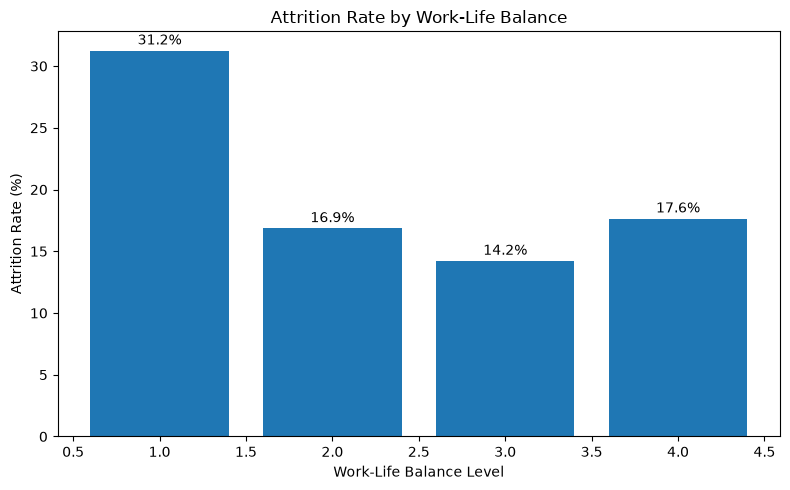

In [29]:
work_life_attrition = (
    df.groupby("work_life_balance")["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    work_life_attrition.index,
    work_life_attrition.values
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Attrition Rate (%)")

for bar, value in zip(bars, work_life_attrition.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 7. Statistical Distribution Check

Before comparing employees who stayed and left, the distribution of key numerical variables is examined to determine whether parametric or non-parametric statistical tests are more appropriate.

In [30]:
from scipy.stats import shapiro

numeric_analysis_cols = [
    "age",
    "monthly_income",
    "years_at_company",
    "total_working_years",
    "job_satisfaction",
    "job_level",
    "distance_from_home",
    "num_companies_worked",
    "years_in_current_role",
    "years_with_curr_manager"
]

normality_results = []

for col in numeric_analysis_cols:
    stat_no, p_no = shapiro(df.loc[df["attrition"] == "No", col])
    stat_yes, p_yes = shapiro(df.loc[df["attrition"] == "Yes", col])

    normality_results.append({
        "column": col,
        "p_value_no": p_no,
        "p_value_yes": p_yes,
        "normal_no": p_no > 0.05,
        "normal_yes": p_yes > 0.05
    })

normality_results = pd.DataFrame(normality_results)

normality_results

,column,p_value_no,p_value_yes,normal_no,normal_yes
0,age,1.106451e-12,1.005180e-07,False,False
1,monthly_income,5.970379e-34,1.502541e-17,False,False
2,years_at_company,1.674441e-32,1.296414e-19,False,False
3,total_working_years,2.095666e-26,2.069465e-14,False,False
4,job_satisfaction,2.875281e-33,2.311557e-14,False,False
5,job_level,6.626868e-34,2.718525e-20,False,False
6,distance_from_home,2.467062e-32,9.869468e-12,False,False
7,num_companies_worked,1.343014e-32,3.523372e-15,False,False
8,years_in_current_role,8.440334e-27,6.261166e-16,False,False
9,years_with_curr_manager,5.981637e-27,2.098845e-15,False,False


## 8. Mann-Whitney U Test

Because the analyzed numerical variables do not meet the normality
assumption in the attrition groups, the non-parametric Mann-Whitney U test
is used to assess whether the distributions differ between employees who
stayed and employees who left.

Null Hypothesis (H₀):
There is no statistically significant difference between the two attrition groups.

Alternative Hypothesis (H₁):
There is a statistically significant difference between the two attrition groups.

Significance level:
α = 0.05

In [31]:
from scipy.stats import mannwhitneyu

test_results = []

for col in numeric_analysis_cols:
    group_no = df.loc[df["attrition"] == "No", col]
    group_yes = df.loc[df["attrition"] == "Yes", col]

    statistic, p_value = mannwhitneyu(
        group_no,
        group_yes,
        alternative="two-sided"
    )

    test_results.append({
        "column": col,
        "u_statistic": statistic,
        "p_value": p_value,
        "significant": p_value < 0.05
    })

mann_whitney_results = pd.DataFrame(test_results)

mann_whitney_results

,column,u_statistic,p_value,significant
0,age,185362.0,5.304342e-11,True
1,monthly_income,191600.5,2.950831e-14,True
2,years_at_company,189639.0,2.916191e-13,True
3,total_working_years,191654.0,2.399569e-14,True
4,job_satisfaction,168858.5,7.957918e-05,True
5,job_level,187491.5,2.956987e-13,True
6,distance_from_home,127995.5,2.387047e-03,True
7,num_companies_worked,139291.5,2.423651e-01,False
8,years_in_current_role,187007.0,4.429560e-12,True
9,years_with_curr_manager,185859.5,1.806754e-11,True


## 9. Multiple Testing Correction

Because multiple statistical tests are performed simultaneously, the
Bonferroni correction is applied to control the family-wise error rate.

A significance level of α = 0.05 is used across the 10 Mann-Whitney U tests.
After Bonferroni correction, 9 of the 10 analyzed numerical variables remain
statistically significant.

`num_companies_worked` is not statistically significant after correction,
suggesting that the number of previous companies worked for does not show
a statistically significant distributional difference between employees
who stayed and employees who left in this dataset.

In [32]:
from statsmodels.stats.multitest import multipletests

reject, p_value_adjusted, _, _ = multipletests(
    mann_whitney_results["p_value"],
    alpha=0.05,
    method="bonferroni"
)

mann_whitney_results["adjusted_p_value"] = p_value_adjusted
mann_whitney_results["significant_adjusted"] = reject

mann_whitney_results

,column,u_statistic,p_value,significant,adjusted_p_value,significant_adjusted
0,age,185362.0,5.304342e-11,True,5.304342e-10,True
1,monthly_income,191600.5,2.950831e-14,True,2.950831e-13,True
2,years_at_company,189639.0,2.916191e-13,True,2.916191e-12,True
3,total_working_years,191654.0,2.399569e-14,True,2.399569e-13,True
4,job_satisfaction,168858.5,7.957918e-05,True,7.957918e-04,True
5,job_level,187491.5,2.956987e-13,True,2.956987e-12,True
6,distance_from_home,127995.5,2.387047e-03,True,2.387047e-02,True
7,num_companies_worked,139291.5,2.423651e-01,False,1.000000e+00,False
8,years_in_current_role,187007.0,4.429560e-12,True,4.429560e-11,True
9,years_with_curr_manager,185859.5,1.806754e-11,True,1.806754e-10,True


## 10. Effect Size: Rank-Biserial Correlation

Because most numerical variables showed statistically significant
differences between employees who stayed and employees who left after
Bonferroni correction, effect size analysis is conducted to assess the
practical magnitude of these differences.

Rank-biserial correlation is used as the effect size measure for the
Mann–Whitney U test.

Effect size interpretation:

- |r| < 0.10  → negligible effect
- |r| < 0.30  → small effect
- |r| < 0.50  → medium effect
- |r| >= 0.50 → large effect

The analysis focuses on the same numerical variables tested in the
Mann–Whitney U analysis.

Effect size should be interpreted together with statistical significance.
A statistically significant result does not necessarily imply a
practically important difference.

In [33]:
effect_size_results = []

for column in numeric_analysis_cols:
    group_no = df.loc[df["attrition"] == "No", column].dropna()
    group_yes = df.loc[df["attrition"] == "Yes", column].dropna()

    u_statistic, p_value = mannwhitneyu(
        group_no,
        group_yes,
        alternative="two-sided"
    )

    n_no = len(group_no)
    n_yes = len(group_yes)

    # Rank-biserial correlation
    r_rb = 1 - (2 * u_statistic) / (n_no * n_yes)

    abs_r = abs(r_rb)

    if abs_r < 0.10:
        effect_interpretation = "Negligible"
    elif abs_r < 0.30:
        effect_interpretation = "Small"
    elif abs_r < 0.50:
        effect_interpretation = "Medium"
    else:
        effect_interpretation = "Large"

    effect_size_results.append({
        "column": column,
        "u_statistic": u_statistic,
        "p_value": p_value,
        "rank_biserial_r": r_rb,
        "absolute_r": abs_r,
        "effect_size": effect_interpretation
    })

effect_size_df = pd.DataFrame(effect_size_results)

effect_size_df.sort_values(
    "absolute_r",
    ascending=False
)

,column,u_statistic,p_value,rank_biserial_r,absolute_r,effect_size
3,total_working_years,191654.0,2.399569e-14,-0.311706,0.311706,Medium
1,monthly_income,191600.5,2.950831e-14,-0.311340,0.311340,Medium
2,years_at_company,189639.0,2.916191e-13,-0.297915,0.297915,Small
5,job_level,187491.5,2.956987e-13,-0.283217,0.283217,Small
8,years_in_current_role,187007.0,4.429560e-12,-0.279901,0.279901,Small
9,years_with_curr_manager,185859.5,1.806754e-11,-0.272048,0.272048,Small
0,age,185362.0,5.304342e-11,-0.268643,0.268643,Small
4,job_satisfaction,168858.5,7.957918e-05,-0.155690,0.155690,Small
6,distance_from_home,127995.5,2.387047e-03,0.123982,0.123982,Small
7,num_companies_worked,139291.5,2.423651e-01,0.046670,0.046670,Negligible


In [34]:
effect_size_summary = (
    effect_size_df
    .merge(
        mann_whitney_results[
            ["column", "adjusted_p_value", "significant_adjusted"]
        ],
        on="column",
        how="left"
    )
    .sort_values("absolute_r", ascending=False)
)

effect_size_summary

,column,u_statistic,p_value,rank_biserial_r,absolute_r,effect_size,adjusted_p_value,significant_adjusted
3,total_working_years,191654.0,2.399569e-14,-0.311706,0.311706,Medium,2.399569e-13,True
1,monthly_income,191600.5,2.950831e-14,-0.311340,0.311340,Medium,2.950831e-13,True
2,years_at_company,189639.0,2.916191e-13,-0.297915,0.297915,Small,2.916191e-12,True
5,job_level,187491.5,2.956987e-13,-0.283217,0.283217,Small,2.956987e-12,True
8,years_in_current_role,187007.0,4.429560e-12,-0.279901,0.279901,Small,4.429560e-11,True
9,years_with_curr_manager,185859.5,1.806754e-11,-0.272048,0.272048,Small,1.806754e-10,True
0,age,185362.0,5.304342e-11,-0.268643,0.268643,Small,5.304342e-10,True
4,job_satisfaction,168858.5,7.957918e-05,-0.155690,0.155690,Small,7.957918e-04,True
6,distance_from_home,127995.5,2.387047e-03,0.123982,0.123982,Small,2.387047e-02,True
7,num_companies_worked,139291.5,2.423651e-01,0.046670,0.046670,Negligible,1.000000e+00,False


## 11. Effect Size Visualization

Rank-biserial correlation is visualized to compare the magnitude of
differences between employees who stayed and employees who left.

Absolute effect size is used to rank the variables by the magnitude
of differences between attrition groups.

The chart focuses on practical magnitude rather than statistical
significance or effect direction.

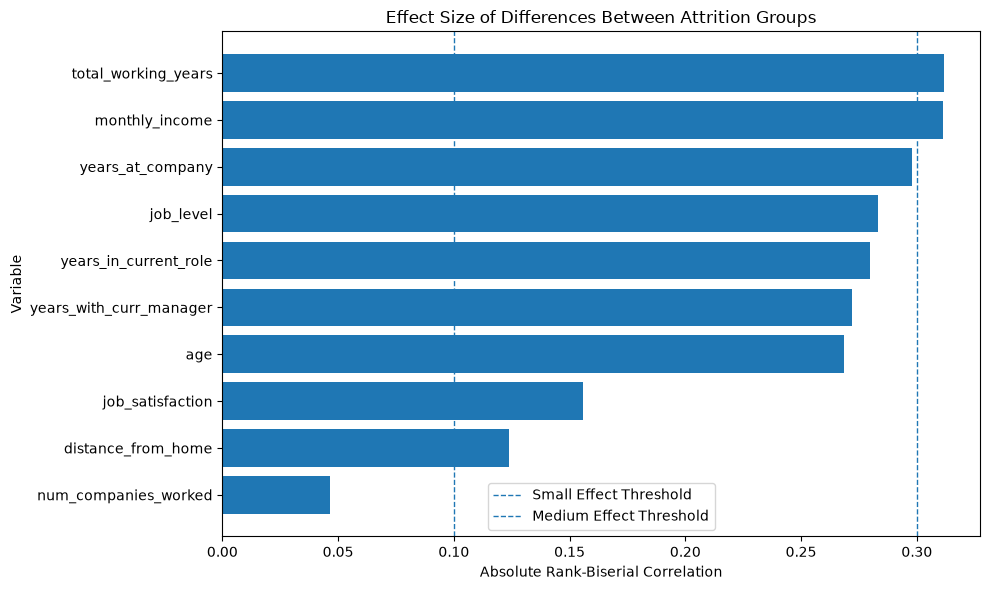

In [35]:
effect_size_plot = effect_size_df.sort_values(
    "absolute_r",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    effect_size_plot["column"],
    effect_size_plot["absolute_r"]
)

plt.axvline(
    0.10,
    linestyle="--",
    linewidth=1,
    label="Small Effect Threshold"
)

plt.axvline(
    0.30,
    linestyle="--",
    linewidth=1,
    label="Medium Effect Threshold"
)

plt.xlabel("Absolute Rank-Biserial Correlation")
plt.ylabel("Variable")
plt.title("Effect Size of Differences Between Attrition Groups")
plt.legend()

plt.tight_layout()
plt.show()

## 12. Statistical Findings

The Mann-Whitney U tests indicate statistically significant distributional
differences between employees who stayed and employees who left for most
of the analyzed numerical variables.

After Bonferroni correction, 9 of the 10 analyzed variables remained
statistically significant, while `num_companies_worked` was not statistically
significant.

After considering effect size, the strongest practical differences were
observed in `total_working_years` and `monthly_income`, both showing medium
effect sizes.

`years_at_company`, `job_level`, `years_in_current_role`,
`years_with_curr_manager`, and `age` showed small effect sizes, indicating
weaker but still measurable differences between attrition groups.

`job_satisfaction` and `distance_from_home` also showed statistically
significant differences, but their practical effects were relatively small.

In contrast, `num_companies_worked` showed a negligible effect size and was
not statistically significant after Bonferroni correction.

These findings suggest that statistical significance alone should not be
interpreted as business importance. Effect size provides additional context
for prioritizing potential attrition factors.

The findings represent associations and distributional differences rather
than causal relationships.

## 13. Business Insights

The exploratory and statistical analysis reveals several patterns
associated with employee attrition.

### 1. Tenure and Experience
Employees who left the company had lower average total working years
(8.24 years vs. 11.86 years) and shorter company tenure
(5.13 years vs. 7.37 years).

Total working years showed the largest effect size (r = 0.31),
while years at company showed a small effect size (r = 0.30).

This suggests that employees with less overall experience and shorter
tenure may represent a higher attrition-risk group.

### 2. Compensation and Job Level
Employees who left had lower average monthly income
(4,787 vs. 6,833) and lower average job level
(1.64 vs. 2.15).

Monthly income showed a medium effect size (r = 0.31), making
compensation one of the more practically important variables associated
with attrition.

The highest attrition rate was also observed among Job Level 1
(26.3%), compared with 9.7% at Job Level 2 and 4.7% at Job Level 4.

### 3. Workload and Work Environment
Employees working overtime had substantially higher attrition
(30.5%) compared with employees without overtime (10.4%).

Business travel also showed a notable pattern, with employees who
travel frequently experiencing a 24.9% attrition rate compared with
8.0% among non-travel employees.

These patterns suggest that workload and work-related travel may be
important areas for employee retention initiatives.

### 4. Job Satisfaction and Work-Life Balance
Employees with lower job satisfaction showed higher attrition.
The attrition rate was 22.8% for satisfaction level 1 compared with
11.3% for level 4.

Similarly, employees with the lowest work-life balance level had an
attrition rate of 31.2%, substantially higher than the overall
attrition rate of 16.1%.

However, job satisfaction had only a small effect size (r = 0.16),
indicating that its statistical relationship with attrition should not
be interpreted as a strong standalone driver.

### 5. Job Role and Employee Profile
Sales Representatives had the highest attrition rate among job roles
at 39.8%, followed by Laboratory Technicians (23.9%) and Human
Resources employees (23.1%).

Single employees also showed higher attrition (25.5%) compared with
married employees (12.5%) and divorced employees (10.1%).

These patterns indicate that attrition may be concentrated within
specific employee segments rather than being evenly distributed across
the workforce.

### 6. Statistical vs. Practical Significance
Nine of the ten numerical variables remained statistically significant
after Bonferroni correction.

However, effect size analysis showed that only total working years and
monthly income reached a medium effect size. The remaining significant
variables showed small effects, while number of companies previously
worked for was not statistically significant after correction.

Therefore, statistical significance should not be treated as evidence
of a strong business impact. The effect size results provide a more
useful basis for prioritizing potential retention factors.